In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [9]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
urls_pool_df = pd.read_csv(SAMPLE_DIR / "_urls_pool.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "_classified_urls.csv")

In [ ]:
print("Number of queries:", len(queries_labeled_df))
print("Number of AI Overviews triggered:", (queries_labeled_df["triggered_ai_overview"] == 'y').sum())
print("Number of pooled documents:", len(urls_pool_df))
print("Number of classified documents:", len(classified_urls_df))

Number of queries: 1000
Number of AI Overviews triggered: 409
Number of pooled documents: 35932
Number of classified documents: 18791


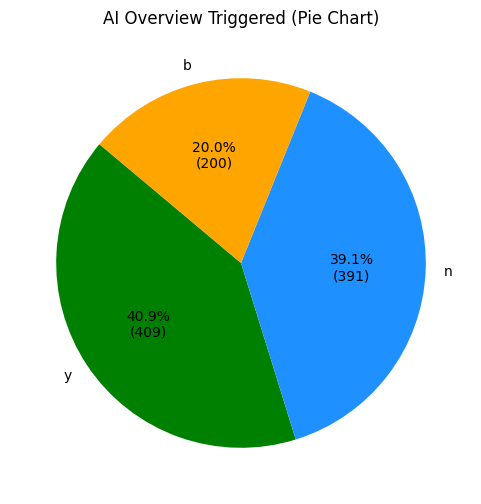

In [6]:
# Distribution of returned AI overview results (Y/N/B) for all queries

counts = queries_labeled_df['triggered_ai_overview'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["y", "n", "b"],
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(counts)))})',
    startangle=140,
    colors=["green", "dodgerblue", "orange"]
)
plt.title("AI Overview Triggered (Pie Chart)")
plt.show()

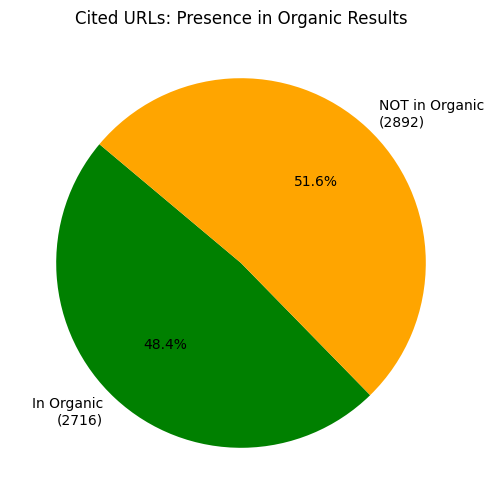

In [24]:
in_organic = 0
not_in_organic = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
        else:
            not_in_organic += 1

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

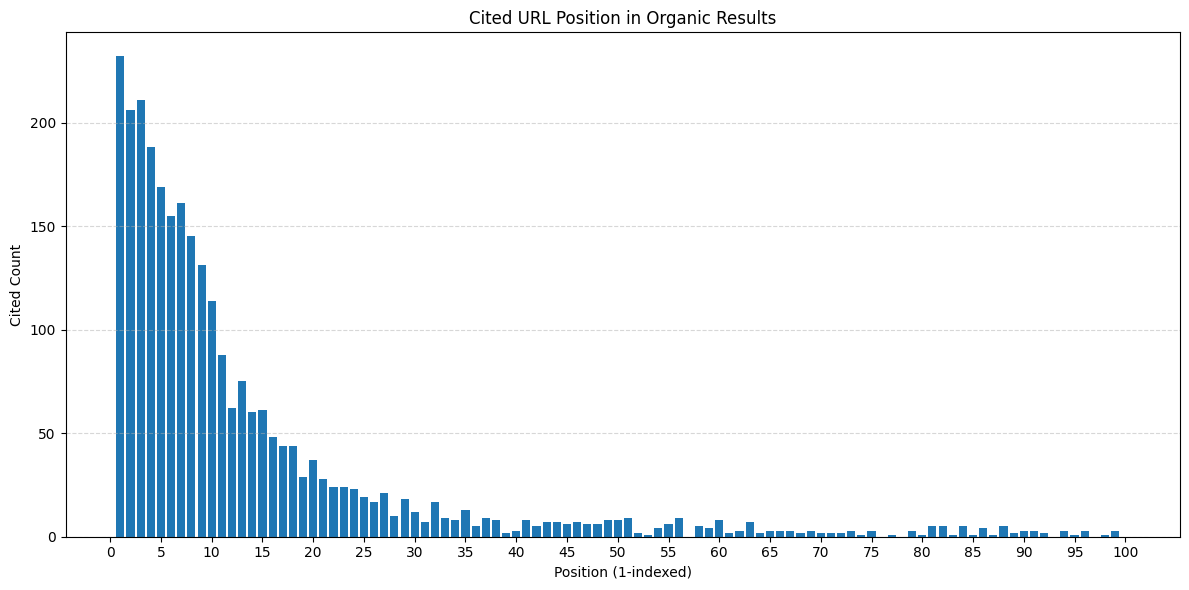

In [16]:
position_counter = Counter()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for i, url in enumerate(organic):
        if url in refs:
            position_counter[i + 1] += 1

positions = list(range(1, 101))
counts = [position_counter.get(i, 0) for i in positions]

plt.figure(figsize=(12, 6))
plt.bar(positions, counts)
plt.title("Cited URL Position in Organic Results")
plt.xlabel("Position (1-indexed)")
plt.ylabel("Cited Count")
plt.xticks(range(0, 101, 5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

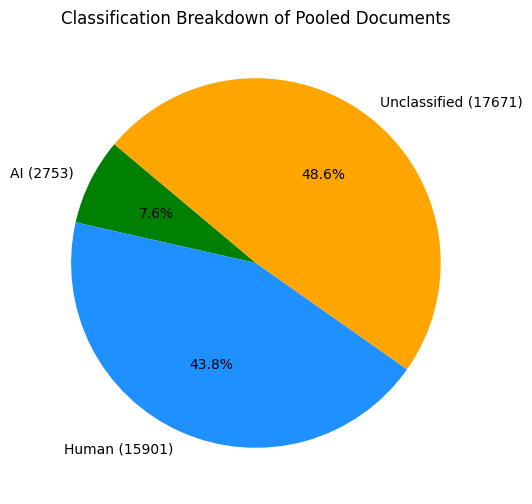

In [25]:
# Identify classified and unclassified
classified_set = set(classified_urls_df["url"])
pool_set = set(urls_pool_df["url"])

failed_to_classify = pool_set - classified_set

# Count AI and Human labels
ai_count = (classified_urls_df["ai_class"] == "AI").sum()
human_count = (classified_urls_df["ai_class"] == "Human").sum()
failed_count = len(failed_to_classify)

# Build pie chart
labels = [
    f"AI ({ai_count})",
    f"Human ({human_count})",
    f"Unclassified ({failed_count})"
]
values = [ai_count, human_count, failed_count]
colors = ["green", "dodgerblue", "orange"]

plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=colors,
    startangle=140
)
plt.title("Classification Breakdown of Pooled Documents")
plt.show()

In [ ]:
# Probability of being cited *per unique document* (cited at least once)

classified_set = set(classified_urls_df["url"])
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Collect cited URLs: ones that appear in both references and organic_results
cited_urls = set()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    cited_urls.update(refs & organic)

# Intersect with classified sets
cited_ai = len(cited_urls & ai_urls)
cited_human = len(cited_urls & human_urls)
total_ai = len(ai_urls)
total_human = len(human_urls)

p_ai = cited_ai / total_ai if total_ai else 0
p_human = cited_human / total_human if total_human else 0

print("P(cited | AI-generated):", f"{p_ai * 100:.2f}%")
print("P(cited | Human-written):", f"{p_human * 100:.2f}%")

P(cited | AI-generated): 7.95%
P(cited | Human-written): 7.91%


In [ ]:
# Probability of being cited *per organic document occurrence*

# Build lookup
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Counters
ai_organic_count = 0
ai_cited_count = 0
human_organic_count = 0
human_cited_count = 0
total_organic_count = 0
total_cited_count = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for url in organic:
        total_organic_count += 1
        if url in refs:
            total_cited_count += 1

        if url in ai_urls:
            ai_organic_count += 1
            if url in refs:
                ai_cited_count += 1
        elif url in human_urls:
            human_organic_count += 1
            if url in refs:
                human_cited_count += 1

# Probabilities
p_overall = total_cited_count / total_organic_count if total_organic_count else 0
p_ai = ai_cited_count / ai_organic_count if ai_organic_count else 0
p_human = human_cited_count / human_organic_count if human_organic_count else 0

print("P(cited | appeared in organic):", f"{p_overall * 100:.2f}%")
print("P(cited | appeared in organic AND AI-classified):", f"{p_ai * 100:.2f}%")
print("P(cited | appeared in organic AND Human-classified):", f"{p_human * 100:.2f}%")

P(cited | appeared in organic): 3.39%
P(cited | appeared in organic AND AI-classified): 10.06%
P(cited | appeared in organic AND Human-classified): 8.57%
